# **TITLE: LINEAR REGRESSION USING PyTorch**

### **OBJECTIVE**

In [42]:
# Import PyTorch and matplotlib
import torch
import matplotlib.pyplot as plt
from torch import nn # nn contains all of PyTorch's building blocks for neural networks

# Check PyTorch version
torch.__version__

'2.12.0'

In [43]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


# 1. Data Preparation

In [44]:
import pandas as pd
import torch

df = pd.read_csv(r'dataset/assignment-data.csv')
df.head(5)

,x,y
0,0.0,2.00
1,0.2,2.12
2,0.4,2.48
3,0.6,3.08
4,0.8,3.92


In [45]:
# Convert to tensors
X = torch.tensor(df["x"].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df["y"].values, dtype=torch.float32).unsqueeze(1)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: torch.Size([50, 1])
y shape: torch.Size([50, 1])


In [46]:
# Train/Test Split (80/20)
train_split = int(0.8 * len(X))

X_train = X[:train_split]
y_train = y[:train_split]

X_test = X[train_split:]
y_test = y[train_split:]

print(f"Total samples: {len(X)}")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Total samples: 50
Training samples: 40
Testing samples: 10


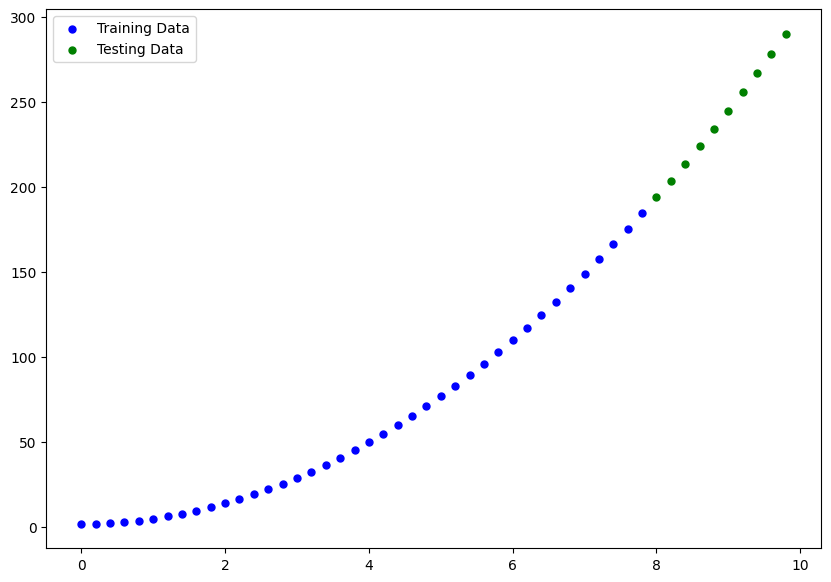

In [47]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):

    plt.figure(figsize=(10, 7))

    plt.scatter(train_data, train_labels,
                c="b", s=25, label="Training Data")

    plt.scatter(test_data, test_labels,
                c="g", s=25, label="Testing Data")

    if predictions is not None:
        plt.scatter(test_data, predictions,
                    c="r", s=25, label="Predictions")

    plt.legend()
    plt.show()


# Visualize original data
plot_predictions()

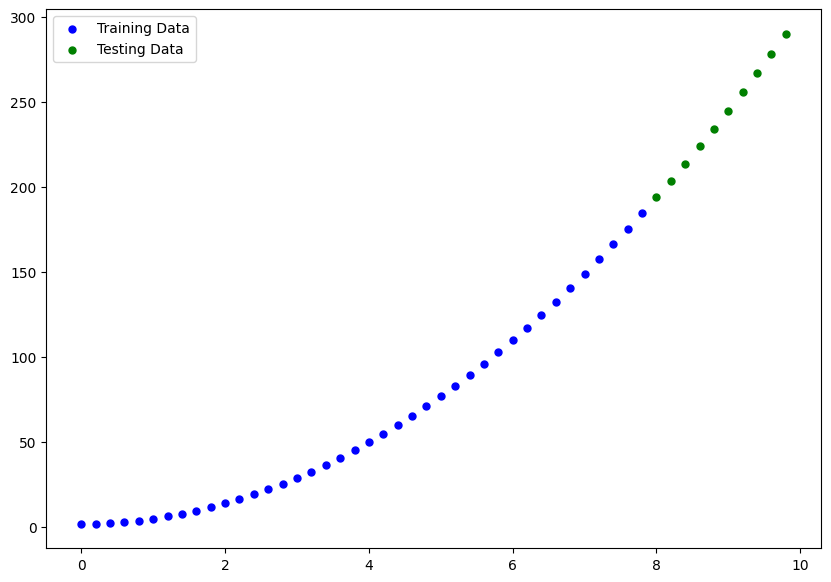

In [48]:
# Note: If you've reset your runtime, this function won't work, 
# you'll have to rerun the cell above where it's instantiated.
plot_predictions(X_train, y_train, X_test, y_test)

## Algorithm Selection

Now we've got some data, let's build a model to use the blue dots to predict the green dots.

We're going to jump right in.

We'll write the code first and then explain everything.

Let's replicate a standard linear regression model using pure PyTorch.

In [49]:
class LinearRegressionModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.weights = nn.Parameter(
            torch.randn(1, dtype=torch.float32),
            requires_grad=True
        )

        self.bias = nn.Parameter(
            torch.randn(1, dtype=torch.float32),
            requires_grad=True
        )

    def forward(self, x):
        return self.weights * x + self.bias


**Pytorch Model building Essentials**

- `torch.nn` : collection of neural-network components (layers, activations, losses) used to build models.
- `torch.nn.Parameter` : a tensor wrapper for model parameters; when requires_grad=True it’s tracked for gradient-based updates.
- `torch.nn.Module` : base class for models/layers; create your network by subclassing it and using its utilities.
- `torch.optim` : optimization algorithms (SGD, Adam, etc.) that update Parameters using gradients.
- `def forward()` : the method you implement in an nn.Module that defines the layer/model’s forward computation on input data.

- [Pytorch Cheat Sheet](https://pytorch.org/tutorials/beginner/ptcheat.html)

In [50]:
torch.manual_seed(42)

# Create model
model_0 = LinearRegressionModel()

print("Initial Parameters:")
print(list(model_0.parameters()))

Initial Parameters:
[Parameter containing:
tensor([0.3367], requires_grad=True), Parameter containing:
tensor([0.1288], requires_grad=True)]


In [51]:
print(model_0.weights.dtype)
print(model_0.bias.dtype)

torch.float32
torch.float32



Initial Predictions:
tensor([[2.8223],
        [2.8897],
        [2.9570],
        [3.0243],
        [3.0917]])

Number of testing samples: 10
Number of predictions made: 10


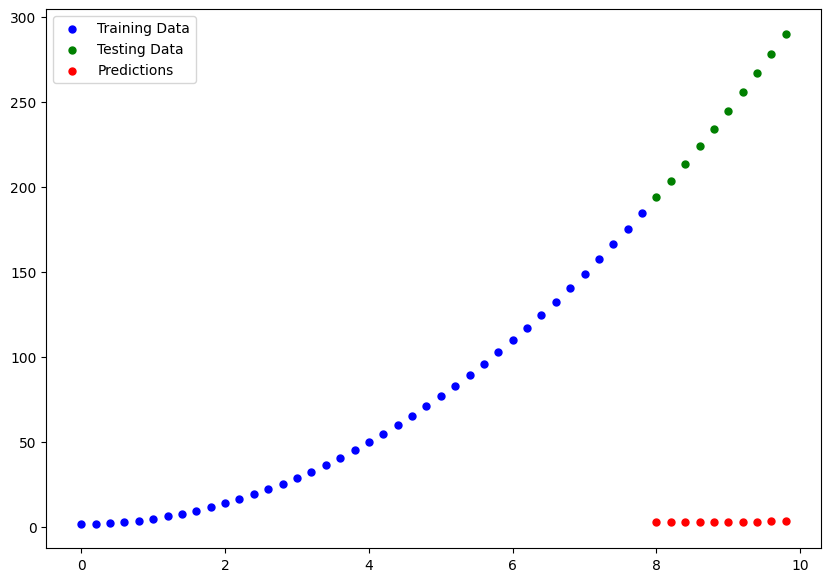

In [52]:
with torch.inference_mode():
    y_preds = model_0(X_test)

print("\nInitial Predictions:")
print(y_preds[:5])

print(f"\nNumber of testing samples: {len(X_test)}")
print(f"Number of predictions made: {len(y_preds)}")

plot_predictions(predictions=y_preds)

- As the name suggests, `torch.inference_mode()` is used when using a model for `inference` (making predictions).
    - it turns off gradient tracking (which is not necessary for inference/prediction)
    

In [53]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[2.8223],
        [2.8897],
        [2.9570],
        [3.0243],
        [3.0917],
        [3.1590],
        [3.2264],
        [3.2937],
        [3.3610],
        [3.4284]])


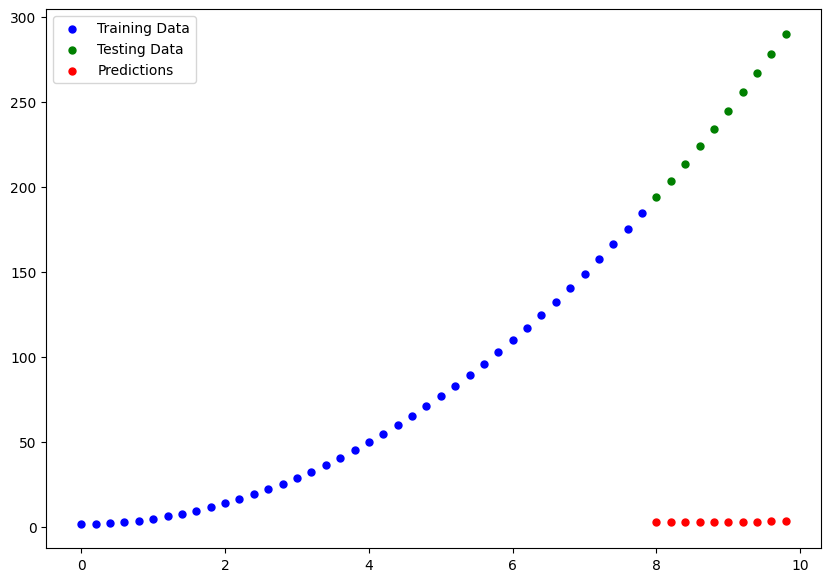

In [54]:
plot_predictions(predictions=y_preds)

### Loss Function Selection

In [55]:
# Create the loss function
loss_fn = nn.L1Loss()  # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(
    params=model_0.parameters(),  # parameters of target model to optimize
    lr=0.1  # learning rate (higher=more updates, lower=slower updates)
)

MAE is the average absolute difference between true values (y_i) and predictions (ŷ_i).
$$\mathrm{MAE} = \frac{1}{n}\sum_{i=1}^{n} \lvert y_i - \hat{y}_i \rvert$$

- Lower MAE → better fit.
- More robust to outliers than MSE (no squaring).

Here, our optimizer is SGD which is short for Stochastic Gradient Descent (SGD). 

The reason for the name: 
- the gradient is computed from a stochastic (random) sample of the training data rather than the entire dataset

### Model Training

In [56]:
torch.manual_seed(42)

epochs = 2000

epoch_count = []
train_loss_values = []
test_loss_values = []

for epoch in range(epochs):

    # ---------------------------
    # Training
    # ---------------------------
    model_0.train()

    y_pred = model_0(X_train)

    loss = loss_fn(y_pred, y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    # ---------------------------
    # Testing
    # ---------------------------
    model_0.eval()

    with torch.inference_mode():

        test_pred = model_0(X_test)

        test_loss = loss_fn(test_pred, y_test)

        if epoch % 10 == 0:

            epoch_count.append(epoch)

            train_loss_values.append(loss.item())
            test_loss_values.append(test_loss.item())

            print(
                f"Epoch: {epoch:3d} | "
                f"Train Loss: {loss:.4f} | "
                f"Test Loss: {test_loss:.4f}"
            )


Epoch:   0 | Train Loss: 62.1781 | Test Loss: 233.9236
Epoch:  10 | Train Loss: 46.1088 | Test Loss: 198.4534
Epoch:  20 | Train Loss: 33.8350 | Test Loss: 167.6266
Epoch:  30 | Train Loss: 26.1252 | Test Loss: 143.4356
Epoch:  40 | Train Loss: 21.8092 | Test Loss: 125.3130
Epoch:  50 | Train Loss: 19.6962 | Test Loss: 113.0420
Epoch:  60 | Train Loss: 18.6653 | Test Loss: 104.5762
Epoch:  70 | Train Loss: 18.1530 | Test Loss: 99.0412
Epoch:  80 | Train Loss: 17.8971 | Test Loss: 95.8703
Epoch:  90 | Train Loss: 17.6795 | Test Loss: 93.4352
Epoch: 100 | Train Loss: 17.5426 | Test Loss: 92.7173
Epoch: 110 | Train Loss: 17.4057 | Test Loss: 91.9994
Epoch: 120 | Train Loss: 17.2688 | Test Loss: 91.2815
Epoch: 130 | Train Loss: 17.1319 | Test Loss: 90.5635
Epoch: 140 | Train Loss: 16.9950 | Test Loss: 89.8456
Epoch: 150 | Train Loss: 16.8581 | Test Loss: 89.1277
Epoch: 160 | Train Loss: 16.7408 | Test Loss: 88.3124
Epoch: 170 | Train Loss: 16.6339 | Test Loss: 87.4553
Epoch: 180 | Train Lo

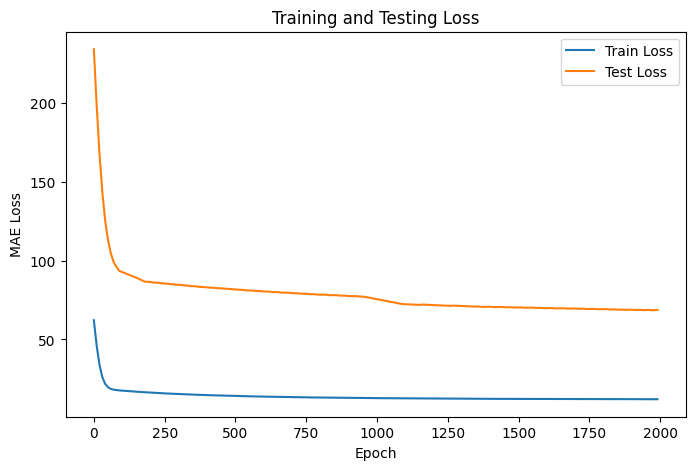

In [57]:

plt.figure(figsize=(8,5))

plt.plot(epoch_count,
         train_loss_values,
         label="Train Loss")

plt.plot(epoch_count,
         test_loss_values,
         label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("MAE Loss")
plt.title("Training and Testing Loss")
plt.legend()
plt.show()


In [58]:
# Find our model's learned parameters
print("The model learned the following values for weights and bias:")
print(model_0.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: 0.7, bias: 0.3")

The model learned the following values for weights and bias:
OrderedDict({'weights': tensor([22.2819]), 'bias': tensor([-26.3010])})

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


*This is the whole idea of machine learning and deep learning, there are some ideal values that describe our data and rather than figuring them out by hand, we can train a model to figure them out programmatically.*

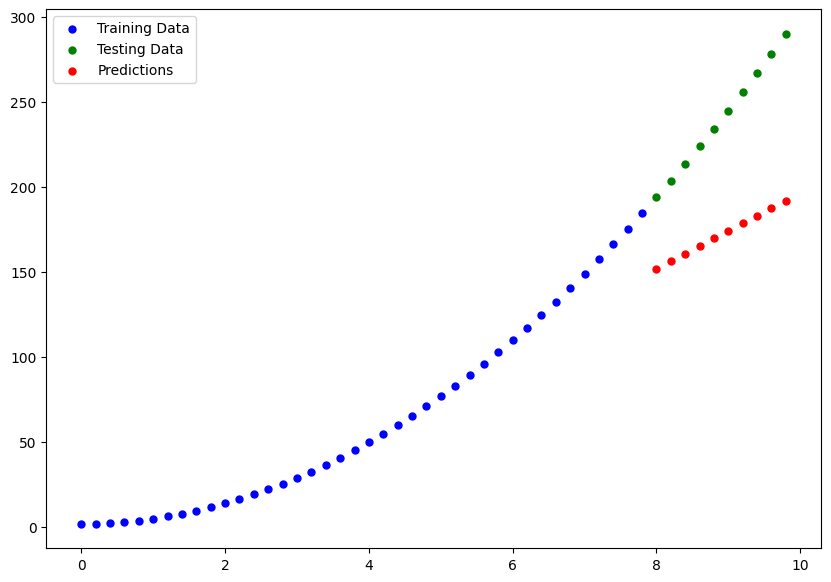

In [59]:
# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  # 3. Make sure the calculations are done with the model and data on the same device
  # in our case, we haven't setup device-agnostic code yet so our data and model are
  # on the CPU by default.
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
plot_predictions(predictions=y_preds)